# Student Performance Analyzer
Submission  Date: September 1st , 2025

Project Team:

Unit 1 (Python Basics & Data Preprocessing): Teena Tom

Unit 2 (Data Structures & OOP): Gokul

Unit 3 (NumPy): Divyang

Unit 4 (Pandas): Adithya

Unit 5 (Matplotlib): Aishik


# Summary
This details the Student Performance Analyzer, Python project designed to execute a complete data analysis workflow on student academic records. The project successfully demonstrates the application of core Python principles and fundamental data science libraries. It ingests raw data from a CSV file, performs robust cleaning and validation, carries out numerical and statistical analysis, and generates a series of insightful visualizations. The modular structure of the project, divided into five distinct units, showcases proficiency in various domains including file handling, object-oriented programming (OOP), and data manipulation with NumPy and Pandas, culminating in clear and informative data visualization using Matplotlib and Seaborn.


# Introduction
**Overview**

The analysis of academic data is crucial for educational institutions to understand student performance, identify trends, and make informed decisions. The Student Performance Analyzer is a command-line application built to automate this process. It provides a systematic approach to transforming raw student records into actionable insights, covering everything from individual student scores to class-wide performance metrics.

**Objectives**

Load and Clean Data: Securely load student data from an external CSV file and perform preprocessing to handle missing values, incorrect data types, and invalid formats.

Apply OOP Concepts: Model real-world entities (students) using classes and objects to create a structured and reusable codebase.

Perform Numerical Analysis: Utilize the NumPy library to conduct efficient mathematical and statistical calculations on student performance data.

Manipulate and Analyze Data: Employ the Pandas library to perform complex data manipulations, including grouping, aggregation, and feature engineering.
Visualize Results: Generate a variety of plots and charts to present the findings in a clear, concise, and visually appealing manner.

Data Preprocessing & Validation
This initial phase, handled by the load_and_clean_data function, is responsible for data ingestion and preparation.

File Handling: The script attempts to load student_records.csv into a Pandas DataFrame. It includes robust try-except error handling to manage a FileNotFoundError, ensuring the program exits gracefully if the data source is missing.

Data Cleaning:
Student names are standardized to title case and stripped of leading/trailing whitespace.
Missing values in the Extracurricular column are filled with the string "None".

**Validation**:
A regular expression (r"^S\d{4,}$") is used to validate the format of each StudentID, ensuring it starts with 'S' followed by at least four digits.
Subject columns are automatically detected. Marks in these columns are converted to a numeric type, with any conversion errors resulting in NaN values. These missing marks are then imputed with the subject's mean score. To ensure data integrity, all scores are clipped to a valid range of 0-100.



Object-Oriented Programming & Data Structures
Class Structure: **bold text**
A base class Student is defined with attributes for name and a dictionary of marks. It includes methods to calculate total marks and display student details.
A GraduateStudent class inherits from Student, extending its functionality with a thesis_topic attribute and overriding the display method to include this additional information.
Data Structures Demonstration: The demonstrate_data_structures function showcases the practical application of:
Dictionary: To map student names to their total marks.
Set: To efficiently store and display all unique grades awarded.
Tuple: To store the immutable details (name and total marks) of the top-performing student.
 Numerical Analysis with NumPy
The perform_numpy_analysis function leverages the high-performance capabilities of the NumPy library.
Array Creation: The 'Total' marks column from the Pandas DataFrame is converted into a NumPy array for efficient numerical computation.
Statistical Aggregation: Key statistical metrics are calculated for the total marks, including the mean, median, standard deviation, maximum, and minimum.
Boolean Masking: A boolean mask is applied to the array to quickly count the number of students who scored above the class average, demonstrating an efficient data filtering technique.
Data Manipulation with Pandas
The core data analysis is conducted in the perform_pandas_analysis function.
Feature Engineering: New, insightful columns are calculated and appended to the DataFrame:
Total: The sum of marks across all subjects.
Percentage: The average of marks across all subjects.
Result: A binary 'Pass'/'Fail' status determined by a 40% threshold.
Grade: A letter grade (F to A+) assigned based on percentage ranges using the pd.cut function.
Grouped Analysis: The groupby() method is used to calculate the mean, max, and min percentage for each class, providing a clear performance comparison.
Pivoting: A pivot_table is created to summarize the average percentage by both class and gender, revealing deeper performance trends.
Targeted Insights: The idxmin() function is applied to find the subject with the lowest average score for each class, identifying areas for improvement.
Data Visualization
This unit translates the analyzed data into visual summaries using Matplotlib and Seaborn.
create_summary_dashboard: Generates a comprehensive dashboard on a single figure with three subplots:
Bar Chart: Displays the average marks for each subject, making it easy to compare subject difficulty.
Pie Chart: Shows the overall distribution of 'Pass' vs. 'Fail' results.
Histogram: Illustrates the frequency distribution of student percentage scores.
create_density_plot: Uses Seaborn's kdeplot to create a smooth density curve of student percentages, offering a clearer view of the distribution's shape and peaks.
create_line_plot: Identifies the top 5 students by total marks and plots their scores across all subjects on a single line graph, allowing for a direct comparison of their individual strengths and weaknesses.

-> Successfully loaded 10000 student records.
-> Detected Subjects: Math, Science, English, History, Computer
-> Data cleaning and validation complete.
-> Calculated Total, Percentage, Result, and Grade for all students.
-> Class-wise Performance Summary:
        mean   max   min
Class                   
5      64.51  88.6  39.2
6      64.75  92.2  37.2
7      64.31  92.4  38.6
8      64.10  90.4  35.4
9      64.38  92.4  37.8
10     64.27  92.2  35.6
11     64.44  95.0  39.8
12     64.28  89.8  41.2

-> Pivot Table: Average Percentage by Class and Gender
Gender  Female   Male
Class                
5        64.49  64.53
6        64.73  64.76
7        64.34  64.29
8        64.32  63.86
9        64.02  64.75
10       64.14  64.41
11       64.54  64.35
12       64.31  64.25

-> Weakest Subject (Lowest Average Score) per Class:
Class
5         Math
6         Math
7         Math
8     Computer
9         Math
10        Math
11     History
12    Computer
dtype: object
-> Calculated Overall St

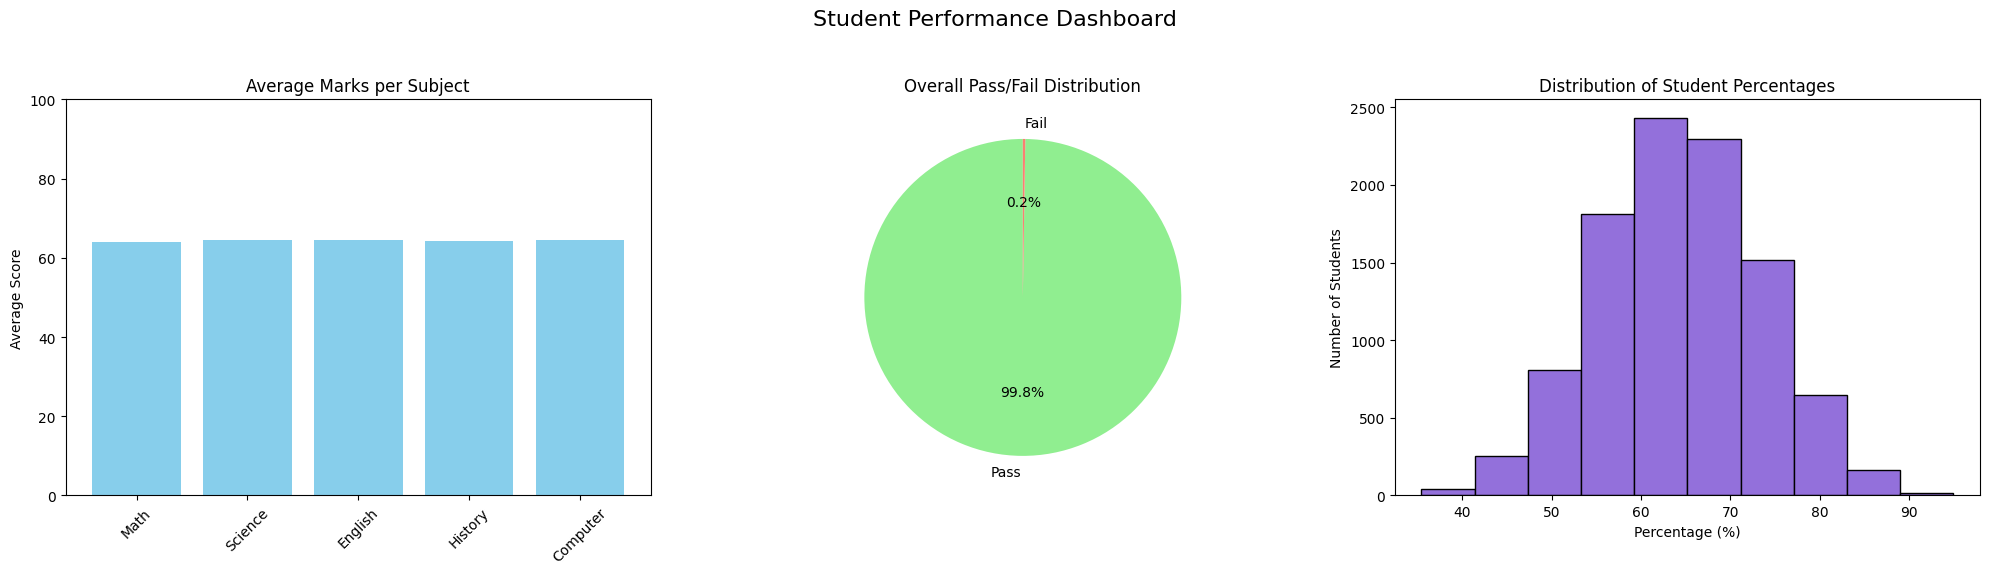

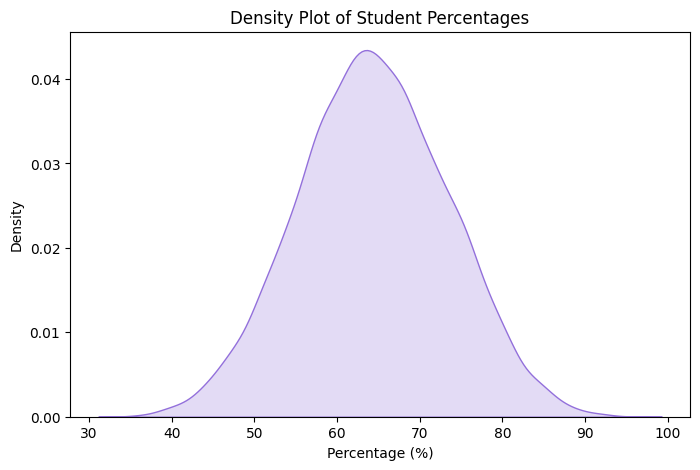


[INFO] Generating a Line Plot for Top 5 Students...


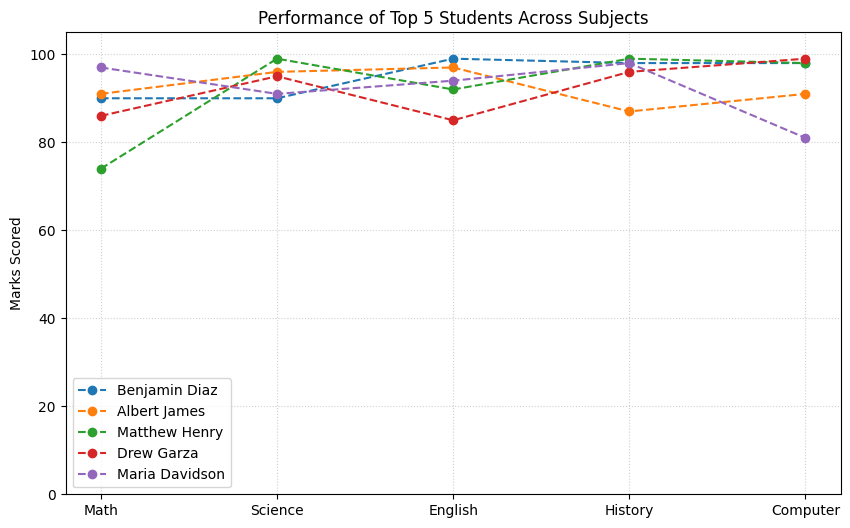

In [ ]:
# =============================================================================
# STUDENT PERFORMANCE ANALYZER
# =============================================================================
#
'''A Python project to load, clean, analyze, and visualize student academic
records. This script demonstrates foundational Python skills, object-oriented
 programming, and the use of key data science libraries like NumPy, Pandas,
and Matplotlib.'''
#
# PROJECT TEAM:
# - Unit 1 (Python Basics): Teena Tom
# - Unit 2 (Data Structures & OOP): Gokul
# - Unit 3 (NumPy): Divyang
# - Unit 4 (Pandas): Adithya
# - Unit 5 (Matplotlib): Aishik
#
# =============================================================================

# --- Imports ---
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Added for density plot

# =============================================================================
# UNIT 1: DATA PREPROCESSING & VALIDATION
# Concepts: Branching, Looping, Lists, Functions, Exception Handling, Modules
# Handled by: Teena Tom
# =============================================================================
def load_and_clean_data(csv_path="student_records.csv"):

    # Loads student data from a CSV, cleans it, and validates formats.
    # Args:
        # csv_path (str): The path to the student records CSV file.
    # Returns:
    # tuple: A tuple containing the cleaned DataFrame and a list of subject names.

    try:
        df = pd.read_csv(csv_path)
        print(f"-> Successfully loaded {df.shape[0]} student records.")
    except FileNotFoundError:
        print(f"[ERROR] The file '{csv_path}' was not found. Please ensure it is in the correct directory.")
        sys.exit()

    df["Name"] = df["Name"].astype(str).str.strip().str.title()
    df["Extracurricular"] = df["Extracurricular"].fillna("None")

    invalid_ids = []
    for index, student_id in df["StudentID"].astype(str).items():
        if not re.match(r"^S\d{4,}$", student_id):
            invalid_ids.append((index, student_id))

    if invalid_ids:
        print(f"-> Found {len(invalid_ids)} StudentID(s) with incorrect format (e.g., '{invalid_ids[0][1]}').")

    standard_cols = [
        "StudentID", "Name", "Class", "Section", "AttendancePercent",
        "Gender", "Extracurricular", "Age", "Total", "Percentage", "Result", "Grade"
    ]
    subjects = [col for col in df.columns if col not in standard_cols]
    print(f"-> Detected Subjects: {', '.join(subjects)}")

    for subj in subjects:
        df[subj] = pd.to_numeric(df[subj], errors='coerce')
        mean_score = df[subj].mean()
        df[subj] = df[subj].fillna(mean_score)
        df[subj] = df[subj].clip(0, 100)

    print("-> Data cleaning and validation complete.")
    return df, subjects

# =============================================================================
# UNIT 2: OBJECT-ORIENTED PROGRAMMING & DATA STRUCTURES
# Concepts: Classes, Instances, Inheritance, Dictionaries, Sets, Tuples
# Handled by: Gokul
# =============================================================================
class Student:
    # A base class to represent a student.
    def __init__(self, name, marks_dict):
        self.name = name
        self.marks = marks_dict

    def get_total_marks(self):
        # Calculates the total marks for the student.
        return sum(self.marks.values())

    def display(self):
        # Prints the student's details.
        print(f"Student: {self.name} | Total Marks: {self.get_total_marks()}")

class GraduateStudent(Student):
    def __init__(self, name, marks_dict, thesis_topic):
        super().__init__(name, marks_dict)
        self.thesis_topic = thesis_topic

    def display(self):
        # Prints the graduate student's details, including the thesis topic.
        print(f"Grad Student: {self.name} | Total: {self.get_total_marks()} | Thesis: '{self.thesis_topic}'")

def demonstrate_data_structures(df):


    name_to_total = dict(zip(df["Name"], df["Total"]))
    print(f"-> Dictionary (Name -> Total) sample: {dict(list(name_to_total.items())[:3])}")

    unique_grades = set(df["Grade"])
    print(f"-> Set (Unique Grades): {unique_grades}")

    top_student_idx = df["Total"].idxmax()
    top_student_details = (df.at[top_student_idx, "Name"], df.at[top_student_idx, "Total"])
    print(f"-> Tuple (Top Student Details): {top_student_details}")

# =============================================================================
# UNIT 3: NUMERICAL ANALYSIS WITH NUMPY
# Concepts: NumPy Arrays, Aggregations, Boolean Masking
# Handled by: Divyang
# =============================================================================
def perform_numpy_analysis(df):


    total_marks_array = np.array(df["Total"])

    stats = {
        "Mean Total Marks": round(total_marks_array.mean(), 2),
        "Median Total Marks": np.median(total_marks_array),
        "Standard Deviation": round(total_marks_array.std(), 2),
        "Highest Total": total_marks_array.max(),
        "Lowest Total": total_marks_array.min()
    }
    print("-> Calculated Overall Statistics:")
    for key, value in stats.items():
        print(f"   - {key}: {value}")

    above_average_count = total_marks_array[total_marks_array > stats["Mean Total Marks"]].shape[0]
    print(f"-> {above_average_count} students scored above the mean total.")
    return stats

# =============================================================================
# UNIT 4: DATA MANIPULATION WITH PANDAS
# Concepts: Indexing, Grouping,Handling Missing Data
# Handled by: Adithya
# =============================================================================
def perform_pandas_analysis(df, subjects):


    df_analysis = df.copy()

    df_analysis["Total"] = df_analysis[subjects].sum(axis=1)
    df_analysis["Percentage"] = df_analysis[subjects].mean(axis=1)
    df_analysis["Result"] = np.where(df_analysis["Percentage"] >= 40, "Pass", "Fail")
    grade_bins = [0, 40, 50, 60, 70, 80, 90, 101]
    grade_labels = ['F', 'D', 'C', 'B', 'B+', 'A', 'A+']
    df_analysis["Grade"] = pd.cut(df_analysis["Percentage"], bins=grade_bins, labels=grade_labels, right=False)
    print("-> Calculated Total, Percentage, Result, and Grade for all students.")

    class_performance = df_analysis.groupby("Class")["Percentage"].agg(['mean', 'max', 'min']).round(2)
    print("-> Class-wise Performance Summary:")
    print(class_performance)

    gender_pivot = pd.pivot_table(df_analysis, values='Percentage', index='Class', columns='Gender', aggfunc='mean').round(2)
    print("\n-> Pivot Table: Average Percentage by Class and Gender")
    print(gender_pivot)

    weakest_subject_per_class = df_analysis.groupby("Class")[subjects].mean().idxmin(axis=1)
    print("\n-> Weakest Subject (Lowest Average Score) per Class:")
    print(weakest_subject_per_class)

    return df_analysis

# =============================================================================
# UNIT 5: DATA VISUALIZATION WITH MATPLOTLIB
# Concepts: Simple Plots, Customization, Multiple Subplots
# Handled by: Aishik
# =============================================================================
def create_summary_dashboard(df, subjects):
    # Generates and displays a dashboard of summary visualizations.

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Student Performance Dashboard', fontsize=16)

    # 1. Bar Chart: Average marks per subject
    subject_averages = df[subjects].mean()
    axes[0].bar(subject_averages.index, subject_averages.values, color='skyblue')
    axes[0].set_title('Average Marks per Subject')
    axes[0].set_ylabel('Average Score')
    axes[0].set_ylim(0, 100)
    axes[0].tick_params(axis='x', rotation=45)

    # 2. Pie Chart: Pass vs. Fail distribution
    pass_fail_counts = df["Result"].value_counts()
    axes[1].pie(pass_fail_counts, labels=pass_fail_counts.index, autopct='%1.1f%%',
                colors=['lightgreen', 'salmon'], startangle=90)
    axes[1].set_title('Overall Pass/Fail Distribution')

    # 3. Histogram: Distribution of percentage scores
    axes[2].hist(df['Percentage'], bins=10, color='mediumpurple', edgecolor='black')
    axes[2].set_title('Distribution of Student Percentages')
    axes[2].set_xlabel('Percentage (%)')
    axes[2].set_ylabel('Number of Students')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def create_density_plot(df):
    # Generates a density plot for student percentages.
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df, x='Percentage', fill=True, color='mediumpurple')
    plt.title('Density Plot of Student Percentages')
    plt.xlabel('Percentage (%)')
    plt.ylabel('Density')
    plt.show()

def create_line_plot(df, subjects):
    #Generates a line plot comparing top 5 students.
    top_5_students = df.nlargest(5, 'Total')
    plt.figure(figsize=(10, 6))
    for index, student in top_5_students.iterrows():
        plt.plot(subjects, student[subjects].values, marker='o', linestyle='--', label=student['Name'])
    plt.title('Performance of Top 5 Students Across Subjects')
    plt.ylabel('Marks Scored')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()


# MAIN EXECUTION

def main():

    # to Load and clean data
    student_df, subject_list = load_and_clean_data("student_records.csv")

    # to Perform core analysis with Pandas
    analyzed_df = perform_pandas_analysis(student_df, subject_list)

    # to Perform numerical calculations with NumPy
    perform_numpy_analysis(analyzed_df)

    #  OOP and Data Structures
    student_one_marks = dict(analyzed_df.loc[0, subject_list])
    student_one = Student(name=analyzed_df.loc[0, "Name"], marks_dict=student_one_marks)
    student_one.display()

    grad_student_one = GraduateStudent(name=analyzed_df.loc[1, "Name"],
                                       marks_dict=dict(analyzed_df.loc[1, subject_list]),
                                       thesis_topic="Data Science Applications")
    grad_student_one.display()
    demonstrate_data_structures(analyzed_df)

    # Visualize the results
    create_summary_dashboard(analyzed_df, subject_list)
    create_density_plot(analyzed_df)
    create_line_plot(analyzed_df, subject_list)



if __name__ == "__main__":
    main()

Figure 1: Student Performance Dashboard This dashboard provides a high-level overview. The bar chart indicates subject performance, the pie chart shows the overall pass rate, and the histogram reveals the concentration of student scores.

Figure 2: Density Plot of Student Percentages This plot provides a smoothed representation of the distribution of student percentages, highlighting the most common score ranges.



Figure 3: Performance of Top 5 Students Across Subjects This line plot tracks the individual subject scores of the five highest-scoring students, allowing for a detailed comparison of their academic performance


# Conclusion

the Student Performance Analyzer project successfully achieved all its objectives. It demonstrates a practical, end-to-end data analysis pipeline using Python. The project effectively integrates foundational programming concepts like loops and error handling, object-oriented design, and the powerful capabilities of the core data science stack (Pandas, NumPy, Matplotlib).
The generated analyses and visualizations provide valuable and easily digestible insights into student performance, which can aid educators in curriculum assessment and student support strategies.
